In [1]:
from google.colab import files

uploaded = files.upload()

Saving customer_churn_nn.csv to customer_churn_nn.csv


In [2]:
import pandas as pd

df = pd.read_csv('customer_churn_nn.csv')

df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [3]:
df.shape



(2000, 17)

The dataset contains multiple rows and columns representing customer information used for churn prediction.

In [4]:
df.columns

Index(['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method',
       'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count', 'churn'],
      dtype='object')

In [5]:
df.isnull().sum()

,0
customer_id,0
region,0
plan_type,0
contract_type,0
payment_method,0
tenure_months,0
monthly_charges_inr,0
avg_login_days_per_month,0
support_tickets_last_90_days,0
payment_delay_days,0


The dataset contains multiple features such as region, plan type, and payment method. The target variable is 'churn', which indicates whether a customer leaves the service.

No significant missing values were found in the dataset.

In [6]:
# Remove ID column (it doesn't help in prediction)

df = df.drop('customer_id', axis=1)

The 'customer_id' column was removed as it is only an identifier and does not contribute to the prediction task.

In [7]:
# Convert categorical columns into numbers

df = pd.get_dummies(df, drop_first=True)

Categorical variables were converted into numerical format using one-hot encoding to make them suitable for the neural network.

In [9]:
from sklearn.model_selection import train_test_split


X = df.drop('churn', axis=1)

y = df['churn']



X_train, X_test, y_train, y_test = train_test_split(

    X, y, test_size=0.2, random_state=42

)

The dataset was split into training and testing sets using an 80-20 split.

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

The data was scaled using StandardScaler to bring all features
to a similar range.

In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [20]:
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [21]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [23]:
history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9688 - loss: 0.2493 - val_accuracy: 0.9781 - val_loss: 0.1193
Epoch 2/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0722 - val_accuracy: 0.9781 - val_loss: 0.1031
Epoch 3/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0620 - val_accuracy: 0.9781 - val_loss: 0.1038
Epoch 4/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0576 - val_accuracy: 0.9781 - val_loss: 0.1039
Epoch 5/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0543 - val_accuracy: 0.9781 - val_loss: 0.1040
Epoch 6/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0512 - val_accuracy: 0.9781 - val_loss: 0.1034
Epoch 7/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0481 - val_accuracy: 0.9781 - val_loss: 0.1060
Epoch 8/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0448 - val_accuracy: 0.9781 - val_loss:

In [26]:
loss, acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9850 - loss: 0.0895
Test Accuracy: 0.9850000143051147


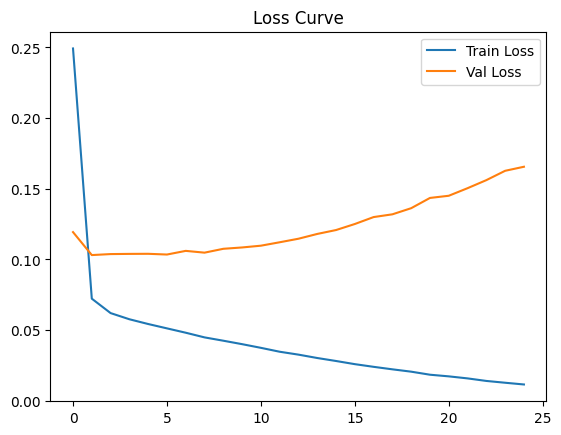

In [29]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

In [31]:
model_exp = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_exp.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_exp = model_exp.fit(
    X_train, y_train,
    epochs=35,   # only change
    batch_size=32,
    validation_split=0.2
)

loss_exp, acc_exp = model_exp.evaluate(X_test, y_test)

print("Experiment Accuracy:", acc_exp)

Epoch 1/35


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9609 - loss: 0.2363 - val_accuracy: 0.9781 - val_loss: 0.1216
Epoch 2/35
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9867 - loss: 0.0817 - val_accuracy: 0.9781 - val_loss: 0.1095
Epoch 3/35
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0699 - val_accuracy: 0.9781 - val_loss: 0.1040
Epoch 4/35
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9867 - loss: 0.0631 - val_accuracy: 0.9781 - val_loss: 0.1017
Epoch 5/35
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9867 - loss: 0.0577 - val_accuracy: 0.9781 - val_loss: 0.1002
Epoch 6/35
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.0528 - val_accuracy: 0.9781 - val_loss: 0.1014
Epoch 7/35
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.0488 - val_accuracy: 0.9781 - val_loss: 0.1028
Epoch 8/35
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.0447 - val_accuracy: 0.9781 - val_loss: 0.1010
Ep

In [32]:
print("Baseline Accuracy:", acc)
print("Experiment Accuracy:", acc_exp)

Baseline Accuracy: 0.9850000143051147
Experiment Accuracy: 0.9825000166893005


1    Weights and biases help the model learn patterns by adjusting feature importance.
   
2     Activation functions introduce non-linearity, enabling the model to capture complex relationships.
   
3    A high learning rate can cause instability, while a low learning rate slows down learning.
   
4    Increasing the number of epochs improved model learning initially but also showed signs of overfitting